In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    r2_score, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Exploration

In [2]:
# Load data
df = pd.read_csv('Students_Performance_Dataset_10k.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nFirst Few Rows:')
print(df.head())

Dataset Shape: (10000, 23)

Column Names:
['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

Data Types:
Student_ID                        str
First_Name                        str
Last_Name                         str
Email                             str
Gender                            str
Age                             int64
Department                        str
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Tota

## 2. Data Cleaning and Preprocessing

In [3]:
# Handle missing values
print('Missing Values Before Cleaning:')
print(df.isnull().sum())

# Fill numeric columns with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df.drop_duplicates(inplace=True)

print(f'\nDataset Shape After Cleaning: {df.shape}')
print(f'Missing Values After Cleaning: {df.isnull().sum().sum()}')

Missing Values Before Cleaning:
Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                   0
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                  0
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        2059
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64

Dataset Shape After Cleaning: (10000, 23)
Missing Values After Cleaning: 0


## 3. Feature Engineering

In [4]:
# Create target variable
df['Pass_Fail'] = (df['Grade'].isin(['A', 'B', 'C'])).astype(int)

print('Pass/Fail Distribution:')
print(df['Pass_Fail'].value_counts())
print('\nPass Rate:', f"{df['Pass_Fail'].mean()*100:.1f}%")

# Select features for modeling
best_features = [
    'Midterm_Score',        # Early score component
    'Assignments_Avg',      # Assessment component
    'Quizzes_Avg',          # Assessment component
    'Projects_Score',       # Assessment component
    'Participation_Score',  # Engagement component
    'Attendance (%)',       # Behavioral metric
    'Study_Hours_per_Week'  # Behavioral metric
]

df_model = df[best_features + ['Final_Score', 'Pass_Fail']].copy()

print('\nFeatures for Modeling:')
print(df_model.describe())

Pass/Fail Distribution:
Pass_Fail
1    5482
0    4518
Name: count, dtype: int64

Pass Rate: 54.8%

Features for Modeling:
       Midterm_Score  Assignments_Avg   Quizzes_Avg  Projects_Score  \
count   10000.000000     10000.000000  10000.000000    10000.000000   
mean       70.687882        74.926700     74.784390       74.725759   
std        16.778182        13.908784     13.894928       13.911928   
min        40.000000        50.000000     50.000000       50.000000   
25%        57.507500        63.907500     63.547500       63.567500   
50%        70.670000        74.850000     74.690000       74.525000   
75%        84.100000        85.840000     85.910000       85.860000   
max        99.990000        99.990000     99.990000      100.000000   

       Participation_Score  Attendance (%)  Study_Hours_per_Week  \
count         10000.000000    10000.000000          10000.000000   
mean             50.340466       75.482178             17.592747   
std              28.065647       1

## 4. Data Preparation for Modeling

In [5]:
# Prepare X and y
X = df_model[best_features]
y_reg = df_model['Final_Score']
y_clf = df_model['Pass_Fail']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print(f'Training Set Size: {len(X_train_r)}')
print(f'Test Set Size: {len(X_test_r)}')
print(f'\nFeature Dimensions: {X.shape[1]} features')

Training Set Size: 8000
Test Set Size: 2000

Feature Dimensions: 7 features


## 5. Model 1: Linear Regression (Score Prediction)

In [6]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = lr.predict(X_test_r)

# Evaluation
r2 = r2_score(y_test_r, y_pred_r)
mae = np.mean(np.abs(y_test_r - y_pred_r))

# Cross-validation
cv_r2 = cross_val_score(lr, X, y_reg, cv=5, scoring='r2')

print('LINEAR REGRESSION - FINAL SCORE PREDICTION')
print('=' * 60)
print(f'Test R² Score: {r2:.4f}')
print(f'Test MAE: {mae:.2f} points')
print(f'\n5-Fold Cross-Validation R² Scores: {cv_r2.round(4)}')
print(f'Mean CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f})')

LINEAR REGRESSION - FINAL SCORE PREDICTION
Test R² Score: -0.0020
Test MAE: 13.86 points

5-Fold Cross-Validation R² Scores: [-0.004  -0.0006 -0.0022 -0.002   0.0005]
Mean CV R²: -0.0017 (±0.0015)


## 6. Model 2: Logistic Regression (Pass/Fail Classification)

In [7]:
# Train Logistic Regression
lg = LogisticRegression(max_iter=1000, random_state=42)
lg.fit(X_train_c, y_train_c)

# Predictions
y_pred_c = lg.predict(X_test_c)
y_pred_proba = lg.predict_proba(X_test_c)[:, 1]

# Evaluation metrics
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_pred_proba)

# Cross-validation
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(lg, X, y_clf, cv=cv_strat, scoring='accuracy')
cv_auc = cross_val_score(lg, X, y_clf, cv=cv_strat, scoring='roc_auc')

print('LOGISTIC REGRESSION - PASS/FAIL CLASSIFICATION')
print('=' * 60)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print(f'Test ROC-AUC: {roc_auc:.4f}')
print(f'Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
print(f'\n5-Fold CV Accuracy Scores: {cv_acc.round(4)}')
print(f'Mean CV Accuracy: {cv_acc.mean():.4f} (±{cv_acc.std():.4f})')
print(f'\n5-Fold CV ROC-AUC Scores: {cv_auc.round(4)}')
print(f'Mean CV ROC-AUC: {cv_auc.mean():.4f} (±{cv_auc.std():.4f})')

LOGISTIC REGRESSION - PASS/FAIL CLASSIFICATION
Test Accuracy: 0.7650 (76.5%)
Test ROC-AUC: 0.8439
Precision: 0.7740 | Recall: 0.7983 | F1: 0.7860

5-Fold CV Accuracy Scores: [0.7445 0.7525 0.749  0.7675 0.763 ]
Mean CV Accuracy: 0.7553 (±0.0086)

5-Fold CV ROC-AUC Scores: [0.8313 0.844  0.8366 0.8557 0.8369]
Mean CV ROC-AUC: 0.8409 (±0.0084)


## 7. Confusion Matrix Analysis

CONFUSION MATRIX
True Negatives: 667
False Positives: 252
False Negatives: 218
True Positives: 863

Sensitivity (Recall): 0.7983
Specificity: 0.7258


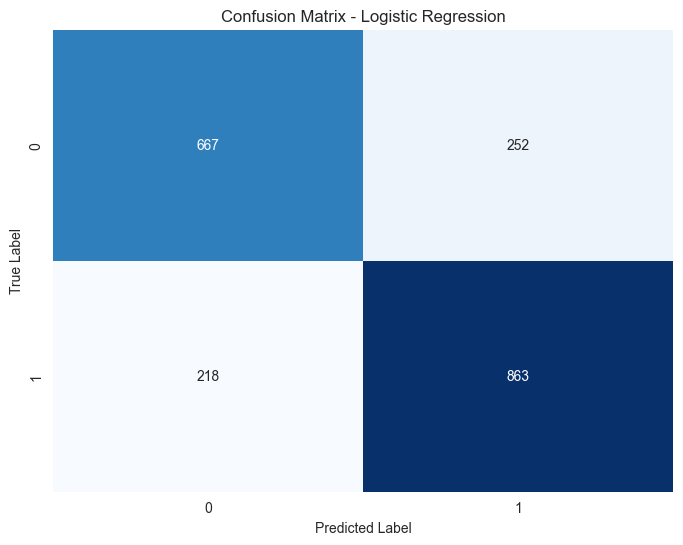

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print('CONFUSION MATRIX')
print('=' * 60)
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')
print(f'\nSensitivity (Recall): {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 8. Model 3: Random Forest (Ensemble Validation)

In [9]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_c, y_train_c)

# Predictions
y_pred_rf = rf.predict(X_test_c)

# Evaluation
acc_rf = accuracy_score(y_test_c, y_pred_rf)
auc_rf = roc_auc_score(y_test_c, rf.predict_proba(X_test_c)[:, 1])
cv_rf_acc = cross_val_score(rf, X, y_clf, cv=cv_strat, scoring='accuracy')

print('RANDOM FOREST - ENSEMBLE VALIDATION')
print('=' * 60)
print(f'Test Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f}%)')
print(f'Test ROC-AUC: {auc_rf:.4f}')
print(f'\n5-Fold CV Accuracy: {cv_rf_acc.mean():.4f} (±{cv_rf_acc.std():.4f})')

RANDOM FOREST - ENSEMBLE VALIDATION
Test Accuracy: 0.7535 (75.3%)
Test ROC-AUC: 0.8372

5-Fold CV Accuracy: 0.7513 (±0.0099)


## 9. Feature Importance

FEATURE IMPORTANCE (Random Forest)
             Feature  Importance
      Projects_Score    0.221733
       Midterm_Score    0.211312
     Assignments_Avg    0.168417
 Participation_Score    0.152186
         Quizzes_Avg    0.117627
      Attendance (%)    0.064868
Study_Hours_per_Week    0.063857


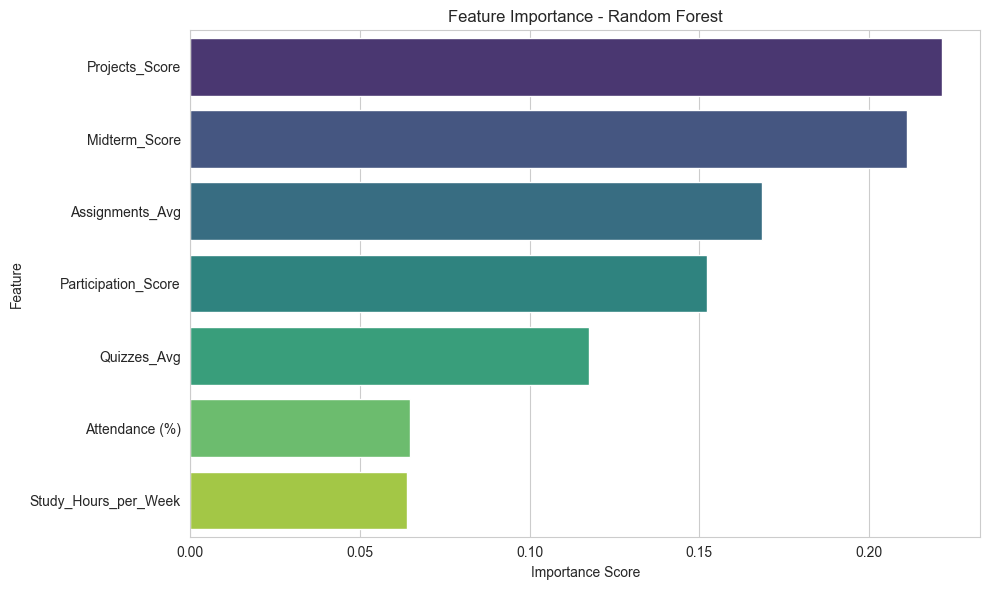

In [10]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': best_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE (Random Forest)')
print('=' * 60)
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. At-Risk Student Identification

In [11]:
# Add predictions to original dataframe
df_results = df.copy()
df_results['Predicted_Pass_Fail'] = lg.predict(X)
df_results['Pass_Probability'] = lg.predict_proba(X)[:, 1]

# Identify at-risk students (low pass probability)
at_risk = df_results[df_results['Pass_Probability'] < 0.5].copy()
at_risk = at_risk.sort_values('Pass_Probability')

print('AT-RISK STUDENT IDENTIFICATION')
print('=' * 60)
print(f'Total At-Risk Students (Pass Probability < 0.5): {len(at_risk)}')
print(f'Percentage of Total: {len(at_risk)/len(df)*100:.1f}%')
print('\nTop 10 At-Risk Students:')
print(at_risk[['Student_ID', 'First_Name', 'Last_Name', 'Attendance (%)', 'Study_Hours_per_Week', 'Final_Score', 'Pass_Probability']].head(10).to_string(index=False))

AT-RISK STUDENT IDENTIFICATION
Total At-Risk Students (Pass Probability < 0.5): 4319
Percentage of Total: 43.2%

Top 10 At-Risk Students:
Student_ID First_Name Last_Name  Attendance (%)  Study_Hours_per_Week  Final_Score  Pass_Probability
    S10828       Omar       Ali           54.62                 12.37        63.90          0.002945
     S3694      Maria     Jones           86.43                 21.80        65.56          0.004234
     S8476       Emma       Lee           62.43                 30.00        57.92          0.004410
     S3861       Liam   Johnson           92.43                 24.00        57.78          0.004728
     S4380      Ahmed     Smith           53.84                 26.00        78.85          0.005367
     S3223      Ahmed     Brown           83.96                 25.30        94.20          0.005387
    S10696       Liam    Garcia           81.92                 14.17        96.33          0.005554
     S2147       Sara     Jones           70.78       

## 11. Model Comparison Summary

In [12]:
# Summary comparison
print('MODEL PERFORMANCE SUMMARY')
print('=' * 60)
print('\nLinear Regression (Score Prediction):')
print(f'  R² = {r2:.4f}')
print(f'  CV R² = {cv_r2.mean():.4f} (consistent across folds)')
print('\nLogistic Regression (Pass/Fail Classification):')
print(f'  Accuracy = {acc*100:.1f}%')
print(f'  ROC-AUC = {roc_auc:.4f}')
print(f'  CV Accuracy = {cv_acc.mean()*100:.1f}% (validated)')
print(f'  CV ROC-AUC = {cv_auc.mean():.4f} (validated)')
print('\nRandom Forest (Ensemble):')
print(f'  Accuracy = {acc_rf*100:.1f}%')
print(f'  ROC-AUC = {auc_rf:.4f}')
print(f'  CV Accuracy = {cv_rf_acc.mean()*100:.1f}%')
print('\n' + '=' * 60)
print('CONCLUSION: Models are consistent across validation folds.')
print('Logistic Regression is recommended for pass/fail prediction.')

MODEL PERFORMANCE SUMMARY

Linear Regression (Score Prediction):
  R² = -0.0020
  CV R² = -0.0017 (consistent across folds)

Logistic Regression (Pass/Fail Classification):
  Accuracy = 76.5%
  ROC-AUC = 0.8439
  CV Accuracy = 75.5% (validated)
  CV ROC-AUC = 0.8409 (validated)

Random Forest (Ensemble):
  Accuracy = 75.3%
  ROC-AUC = 0.8372
  CV Accuracy = 75.1%

CONCLUSION: Models are consistent across validation folds.
Logistic Regression is recommended for pass/fail prediction.
